# Rare Disease Outlier Expression Practicum Using OUTRIDER

Welcome to this R-code-based Notebook that will take you through a real world
tour of the bioinformatics of outlier expression detection for rare diseases. Aberrant gene expression has the potential to perturb normal biological function.  Gene expression might be affected by an easily detectable promoter or nonsense variant, but might equally be due to a less discoverable variant in a distal and potentially uncharacterized enhancer region or similar.  Profiling outlier gene expression enables us to identify significantly abrogated gene expression in an individual's genes, when compared to a cohort of individuals who do not have the same condition.  Furthermore, this can be performed in the absence of or in combination with available DNA variant information.


## Install Dependencies

To get started click on the next cell of code and hit shift-enter **or click the play icon in the upper-left corner** to run the code. **_Run this first block of code while listening to the lecture_,** since this will install into your Google Colab environment all the necessary dependencies and load in our example data set. 

In [ ]:
system("sudo apt-get -y install libxml2-dev")
system("sudo apt-get -y install libxml2")
install.packages("devtools")
devtools::install_version("XML",version = "3.98-1.20", repos = "http://cran.us.r-project.org")
install.packages(c("BiocManager","dplyr"))
BiocManager::install("OUTRIDER")
library(OUTRIDER)
library(dplyr)
# Download necessary files
system('wget --recursive --no-parent --reject="index.html*" -nH --cut-dirs=3 path removed)
print("done installing packages and downloading data")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'?repositories' for details

replacement repositories:
    CRAN: https://cran.rstudio.com


Bioconductor version 3.13 (BiocManager 1.30.16), R 4.1.0 (2021-05-18)

Installing package(s) 'BiocVersion', 'OUTRIDER'

also installing the dependencies ‘iterators’, ‘formatR’, ‘png’, ‘bit’, ‘Rhtslib’, ‘rjson’, ‘filelock’, ‘xtable’, ‘foreach’, ‘gtools’, ‘caTools’, ‘lambda.r’, ‘futile.options’, ‘GenomeInfoDbData’, ‘KEGGREST’, ‘bit64’, ‘plogr’, ‘bitops’, ‘zlibbioc’, ‘Rsamtools’, ‘GenomicAlignments’, ‘restfulr’, ‘BiocFileCache’, ‘annotate’, ‘gridExtra’, ‘TSP’, ‘qap’, ‘gclus’, ‘gplots’, ‘registry’, ‘later’, ‘futile.logger’, ‘snow’, ‘GenomeInfoDb’, ‘AnnotationDbi’, ‘RSQLite’, ‘RCurl’, 

[1] "done installing packages and downloading data"


## Quickstart with OUTRIDER

We begin here by showing the most basic usage of OUTRIDER using the toy data that is included with the package. In the subsequent sections we will take a deeper dive in more realistic data.

Throughout this tutorial, we will assume that a standard RNA-seq expression pipeline has been run that will provide gene expression quantification in the form of a read count per gene. These results are generated by aligning next-generation sequencing reads to the human reference genome using an RNA alignment algorithm (e.g. <a href="https://ccb.jhu.edu/software/tophat/index.shtml">Tophat</a> or <a href="https://github.com/alexdobin/STAR">STAR</a>), followed by a read counting algorithm (e.g. <a href="https://sourceforge.net/projects/subread/">featureCounts</a>), or using a pseudoaligner algorithm to combine these steps (e.g., [salmon](https://salmon.readthedocs.io/en/latest/salmon.html) or [kallisto](https://pachterlab.github.io/kallisto/about)).  OUTRIDER requires gene expression counts for multiple individuals in a matrix format where genes are rows and individuals are columns, as you will see next.

In [ ]:
# load in demo file that comes with OUTRIDER
demoFile <- system.file('extdata', 'KremerNBaderSmall.tsv',package='OUTRIDER')
df <- read.table(demoFile, check.names=FALSE)

# Examine the counts file
head(df)
nrow(df)

,65937,66623,69245,69248,69456,70038,70041,74123,76619,76620,⋯,MUC1422,MUC1424,MUC1427,MUC1420,MUC1428,MUC1410,MUC1411,MUC1384,MUC1412,MUC1436
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
DDX11L1,10,17,0,15,7,11,12,14,9,10,⋯,4,20,67,5,34,12,4,4,2,4
OR4F5,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
M37726,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
LOC643837,626,525,1268,539,726,593,421,399,362,383,⋯,648,763,793,677,598,665,568,476,596,566
AK056486,5,7,44,14,54,8,69,35,96,94,⋯,10,72,109,2,5,10,18,11,35,50
SAMD11,317,126,1302,61,1163,287,1248,209,2770,2510,⋯,51,1655,2643,59,59,139,125,42,685,1638


[1] 999

Here we can see that this toy dataset has 999 genes worth of data in 119 patients. Despite the relatively small size, the OUTRIDER modeling will still require about a minute to produce its results.  The following code will perform basic QC, utilize OUTRIDER's autoencoder to correct for confounding factors in the data, and identify genes per individual that appear to be outliers versus the rest of the cohort.  Go ahead and run it now.

In [ ]:
# Load data into OUTRIDER
ods <- OutriderDataSet(countData=df)
# Filter lowly expressed genes
ods <- filterExpression(ods, minCounts=TRUE, filterGenes=TRUE)
# Run OUTRIDER to correct for confounders
ods <- OUTRIDER(ods)
# Get the (significant) results in a table
res <- results(ods)
head(res)

229 genes did not pass the filter due to zero counts. This is 22.9% of the genes.

Mon Jun 21 18:02:06 2021: SizeFactor estimation ...

Mon Jun 21 18:02:06 2021: Controlling for confounders ...

Using estimated q with: 23

Mon Jun 21 18:02:07 2021: Using the autoencoder implementation for controlling.



[1] "Mon Jun 21 18:02:07 2021: Initial PCA loss: 4.73997327486604"
[1] "Mon Jun 21 18:03:02 2021: Iteration: 1 loss: 4.19551565209768"
[1] "Mon Jun 21 18:03:29 2021: Iteration: 2 loss: 4.17573666163257"
[1] "Mon Jun 21 18:03:54 2021: Iteration: 3 loss: 4.16833450844535"
[1] "Mon Jun 21 18:04:20 2021: Iteration: 4 loss: 4.16266198502757"
[1] "Mon Jun 21 18:04:46 2021: Iteration: 5 loss: 4.1592809104641"
[1] "Mon Jun 21 18:05:12 2021: Iteration: 6 loss: 4.1564388426573"
[1] "Mon Jun 21 18:05:38 2021: Iteration: 7 loss: 4.15444231013054"
[1] "Mon Jun 21 18:06:02 2021: Iteration: 8 loss: 4.15365103077434"
[1] "Mon Jun 21 18:06:27 2021: Iteration: 9 loss: 4.15291385424531"
[1] "Mon Jun 21 18:06:51 2021: Iteration: 10 loss: 4.15222289479888"
[1] "Mon Jun 21 18:07:17 2021: Iteration: 11 loss: 4.1508449061526"
[1] "Mon Jun 21 18:07:44 2021: Iteration: 12 loss: 4.14997261724586"
[1] "Mon Jun 21 18:08:10 2021: Iteration: 13 loss: 4.14944221114899"
[1] "Mon Jun 21 18:08:34 2021: Iteration: 14 los

Mon Jun 21 18:08:58 2021: Used the autoencoder implementation for controlling.

Mon Jun 21 18:08:58 2021: P-value calculation ...

Mon Jun 21 18:09:09 2021: Zscore calculation ...



geneID,sampleID,pValue,padjust,zScore,l2fc,rawcounts,normcounts,meanCorrected,theta,aberrant,AberrantBySample,AberrantByGene,padj_rank
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
ATAD3C,MUC1360,3.187100e-11,1.772881e-07,5.26,1.86,948,245.49,86.11,16.67,TRUE,1,1,1
NBPF15,MUC1351,6.171592e-10,3.433057e-06,5.79,0.78,7591,7075.65,4487.58,109.77,TRUE,2,1,1
MSTO1,MUC1367,4.062823e-09,2.260017e-05,-6.22,-0.81,761,727.23,1227.52,150.52,TRUE,1,1,1
HDAC1,MUC1350,1.515767e-08,8.431724e-05,-5.93,-0.78,2215,2130.53,3457.15,138.73,TRUE,1,1,1
DCAF6,MUC1374,6.374220e-08,3.545772e-04,-5.70,-0.62,2348,3075.00,4589.97,195.47,TRUE,1,1,1
NBPF16,MUC1351,2.158032e-07,6.002216e-04,4.85,0.68,4014,3847.72,2610.69,105.49,TRUE,2,1,2


As you can see, using this simple data set we have already succeeded in identifying outlier gene expression.  For the reader's reference, we describe the columns of the output below (which to our knowledge at present is not formally documented in the OUTRIDER package vignette or manual):

- `geneID` : the unique identifier of the gene in question
- `sampleID` : the unique identifier of the sample in question
- `pValue` : the raw p-value in the outlier test
- `padjust` : the mulitple-corrections adjusted p-value in the outlier test
- `zScore` : a measure of how many standard deviations away from the mean (in adjusted log counts)
- `l2fc` : the log2-fold change compared to the mean of the population
- `rawcounts` : the input raw counts for this gene in this proband (that need be integers)
- `normcounts` : the autoencoder-adjusted counts (that need not be integers)
- `meanCorrected` : the population mean in adjusted counts
- `theta` : a statistical model parameter for the negative binomial related to the spread of the distribution (var = mu + [mu^2]/theta)
- `aberrant` : a binary value that is true if the p-value is lower than a threshold and absolute value of the z-score is higher than a threshold (both thresholds adjustable in the calls to OUTRIDER)
- `AberrantBySample` : the number of genes that were aberrant in this sample
- `AberrantByGene` : the number of samples that were aberrant in this gene
- `padj_rank` : the rank of this gene in this proband when genes are sorted by their `padjust` value 

---

##CHECKPOINT 1

---

# A Deeper Dive Using Our Data

In real world data, we often have metadata associated with our RNA-seq samples. For example, various samples might be related to one another (e.g., trio samples, siblings, etc.). Such related individuals might exhibit impaired function of the same gene (or genes) as their related proband, potentially impacting our ability to identify important gene expression outliers. Because of this and since OUTRIDER uses the cohort to build its statistical models, it is advisable to exclude related samples from the model building step.



In [ ]:
# Load in Data and Meta Data
relationsDF <- read.csv("relationships.tsv",stringsAsFactors = FALSE)
head(relationsDF)
dfCount <- read.table(gzfile("counts.tsv.gz"))
head(dfCount)
dfFPKM  <- read.table(gzfile("fpkm.tsv.gz"))
head(dfFPKM)
tail(dfFPKM)

,individual1,hasRelationshipTo,individual2
,<chr>,<chr>,<chr>
1,Proband121,sibling,Proband7
2,Proband80,parent,Proband124
3,Proband25,parent,Proband124
4,Proband123,parent,Proband111
5,Proband116,parent,Proband111
6,Proband38,parent,Proband12


,Proband1,Proband2,Proband3,Proband4,Proband5,Proband6,Proband7,Proband8,Proband9,Proband10,⋯,Proband123,Proband124,Proband125,Proband126,Proband127,Proband128,Proband129,Proband130,Proband131,Proband132
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Gene1,7,21,15,24,25,52,10,26,20,24,⋯,14,38,39,26,19,10,22,27,15,17
Gene2,4,8,2,12,17,31,4,3,4,8,⋯,3,0,0,19,20,0,3,4,11,8
Gene3,0,2,0,6,0,0,2,0,3,0,⋯,0,0,0,1,3,0,0,2,0,1
Gene4,87,288,138,134,223,532,77,102,181,194,⋯,100,241,217,231,165,74,91,219,153,180
Gene5,58,78,58,102,117,51,49,43,74,70,⋯,49,79,71,62,57,18,47,103,79,77
Gene6,0,0,0,0,0,0,0,0,3,0,⋯,0,0,0,4,0,0,0,0,0,0


,Proband1,Proband2,Proband3,Proband4,Proband5,Proband6,Proband7,Proband8,Proband9,Proband10,⋯,Proband123,Proband124,Proband125,Proband126,Proband127,Proband128,Proband129,Proband130,Proband131,Proband132
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Gene1,1.58189028,2.20903956,1.06183799,1.40454306,1.7573223,2.1631622,0.85529415,1.50047708,2.18498374,2.95299311,⋯,1.07316585,3.3853426,2.4206190,2.292780271,1.66267297,0.6089691,1.61780995,2.93222702,1.6592268,1.336269352
Gene2,0.08100351,0.07541187,0.01268711,0.06293187,0.1070843,0.1155615,0.03065780,0.01551468,0.03916010,0.08820775,⋯,0.02060751,0.0000000,0.0000000,0.150144089,0.15683709,0.0000000,0.01976932,0.03892776,0.1090367,0.056350870
Gene3,0.00000000,0.01693867,0.00000000,0.02827093,0.0000000,0.0000000,0.01377243,0.00000000,0.02638788,0.00000000,⋯,0.00000000,0.0000000,0.0000000,0.007099931,0.02113681,0.0000000,0.00000000,0.01748755,0.0000000,0.006328636
Gene4,0.86559728,1.33381317,0.43009501,0.34526053,0.6901358,0.9743516,0.28995095,0.25916390,0.87059286,1.05092382,⋯,0.33748706,0.9452668,0.5929798,0.896849110,0.63570480,0.1984016,0.29462156,1.04711952,0.7451166,0.622925207
Gene5,6.27382095,3.92739525,1.96526356,2.85726024,3.9366162,1.0155042,2.00602984,1.18781904,3.86968613,4.12263647,⋯,1.79787999,3.3687744,2.1093371,2.617017256,2.38755783,0.5246788,1.65435416,5.35422799,4.1828030,2.897087554
Gene6,0.00000000,0.00000000,0.00000000,0.00000000,0.0000000,0.0000000,0.00000000,0.00000000,0.21620322,0.00000000,⋯,0.00000000,0.0000000,0.0000000,0.232686815,0.00000000,0.0000000,0.00000000,0.00000000,0.0000000,0.000000000


,Proband1,Proband2,Proband3,Proband4,Proband5,Proband6,Proband7,Proband8,Proband9,Proband10,⋯,Proband123,Proband124,Proband125,Proband126,Proband127,Proband128,Proband129,Proband130,Proband131,Proband132
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Gene57768,0.00000000,0,0.000000000,0.05794267,0,0.000000000,0,0.000000000,0.00000000,0.0000000,⋯,0.00000000,0,0,0.000000000,0.00000000,0,0.00000000,0.000000000,0.000000000,0.01111787
Gene57769,0.00000000,0,0.000000000,0.00000000,0,0.000000000,0,0.000000000,0.00000000,0.0000000,⋯,0.00000000,0,0,0.000000000,0.01362989,0,0.01145365,0.000000000,0.000000000,0.00000000
Gene57770,0.00000000,0,0.008898242,0.00000000,0,0.000000000,0,0.000000000,0.00000000,0.0000000,⋯,0.00000000,0,0,0.000000000,0.00000000,0,0.00000000,0.000000000,0.000000000,0.00000000
Gene57771,0.01121705,0,0.000000000,0.00000000,0,0.004129678,0,0.005729101,0.07591834,0.0000000,⋯,0.00000000,0,0,0.030639917,0.00000000,0,0.00000000,0.005390565,0.000000000,0.00780325
Gene57772,0.00000000,0,0.017045865,0.00000000,0,0.000000000,0,0.000000000,0.00000000,0.1185122,⋯,0.01845826,0,0,0.084937825,0.00000000,0,0.00000000,0.000000000,0.026635850,0.00000000
Gene57773,0.00000000,0,0.000000000,0.00000000,0,0.000000000,0,0.000000000,0.00000000,0.0000000,⋯,0.00000000,0,0,0.004303657,0.00000000,0,0.00000000,0.005300080,0.005398376,0.00000000


Here for anonymization purposes, we have randomly labeled patients as Proband1,...,Proband132 and the gene IDs as Gene1,...,Gene57773. With these data loaded into memory, we will now use the relationship database to provide a list of samples to exclude from the model building step.   Note that while related samples are excluded from the model building step, they can still be analyzed downstream and used to find outlier genes.

In [ ]:
# exclude related individuals who both have RNAseq data
sampsToExclude <- c()
for(index in seq_along(relationsDF$individual1)){
    indiv1 <- relationsDF$individual1[index]
    indiv2 <- relationsDF$individual2[index]

    # Our database in general might have samples without RNA
    ind1hasRNA <- indiv1 %in% colnames(dfCount)
    ind2hasRNA <- indiv2 %in% colnames(dfCount)
    if(ind1hasRNA && ind2hasRNA){
      sampsToExclude <- c(sampsToExclude,indiv1,indiv2)
    }
}

#make sure no repeats
sampsToExclude <- unique(sampsToExclude)

print(sampsToExclude)

 [1] "Proband121" "Proband7"   "Proband80"  "Proband124" "Proband25" 
 [6] "Proband123" "Proband111" "Proband116" "Proband38"  "Proband12" 
[11] "Proband107" "Proband82"  "Proband91"  "Proband88"  "Proband106"
[16] "Proband79"  "Proband15" 


Since the probands listed above all are familially related to at least one 
other sample in the cohort, they will be excluded to prevent biological factors being incorrectly identified as confounders and adjusted away. Additionally, if the related invidivuals all had outlier expression in the same gene compared to the population, OUTRIDER would over estimate the variability in the population and have reduced power to find these outliers.

Next we need to perform some basic filtering steps that will account for the fact that not all genes are reliably expressed/measured in our tissue sample (i.e., whole blood). While OUTRIDER provides the `filterExpression` function to do this automatically, we suggest doing this manually to retain control of the filtering process and ensure its accuracy. In particular, gene annotations/reference genome utilized in your pipeline may differ from those used by default in `filterExpression`.

In [ ]:
#Filter based on FPKM of gene having 95-th percentile higher than a threshold
fpkmCutoff <- 1
passedFilterFPKMs <- rowQuantiles(as.matrix(dfFPKM), probs=c(0.95)) > fpkmCutoff

#Filter based on non-zero counts occuring in at least 75% of the samples
passedFilterCount <- rowSums(as.matrix(dfCount)>0) > length(dfCount)*3/4

#merge filters and subset count data
passedFilter <- passedFilterFPKMs & passedFilterCount
dfCountFilt   <- dfCount[passedFilter,]

print("done filtering")

[1] "done filtering"


Now we are ready to run OUTRIDER. The next block of code would ordinarily require around 10 minutes to run, so we will skip it and just load the result from a precomputed rds file using the short piece of code that follows it.

In [ ]:
# Comment out the next stop line if you wish to explore this code outside the tutorial
#stop("Do not run this block during the tutorial, it takes too long.")

#ods <- OutriderDataSet(countData=dfCountFilt)

# set which samples are correlated and should be excluded from model building
#sampleExclusionMask(ods) <- FALSE
#sampleExclusionMask(ods[,sampsToExclude]) <- TRUE

# automatically control for confounders
#ods <- estimateSizeFactors(ods)
#ods <- controlForConfounders(ods,BPPARAM=SerialParam()) #MulticoreParam(2)

# fit negative binomial distribution to each feature
#ods <- fit(ods,BPPARAM=SerialParam())

# compute P-values (nominal and adjusted)
#ods <- computePvalues(ods,BPPARAM=SerialParam(), alternative="two.sided", method="BH")
#ods <- computeZscores(ods)

# get all results
#res <- results(ods, all=TRUE)

# save ods to disk
#saveRDS(ods, file="ods.rds")



##Load precomputed results

In [ ]:
#load in precomputed ods object
ods <- readRDS("ods.rds")

# get all results
res <- results(ods, all=TRUE)

print("data loaded and results gathered")

[1] "data loaded and results gathered"


---

##CHECKPOINT 2

---

Now with the results loaded into memory, let's explore the role of the autoencoder.  We will use the plotCountCotHeatmap function to generate plots of correlated gene counts across samples, before and after correction with the autoencoder.

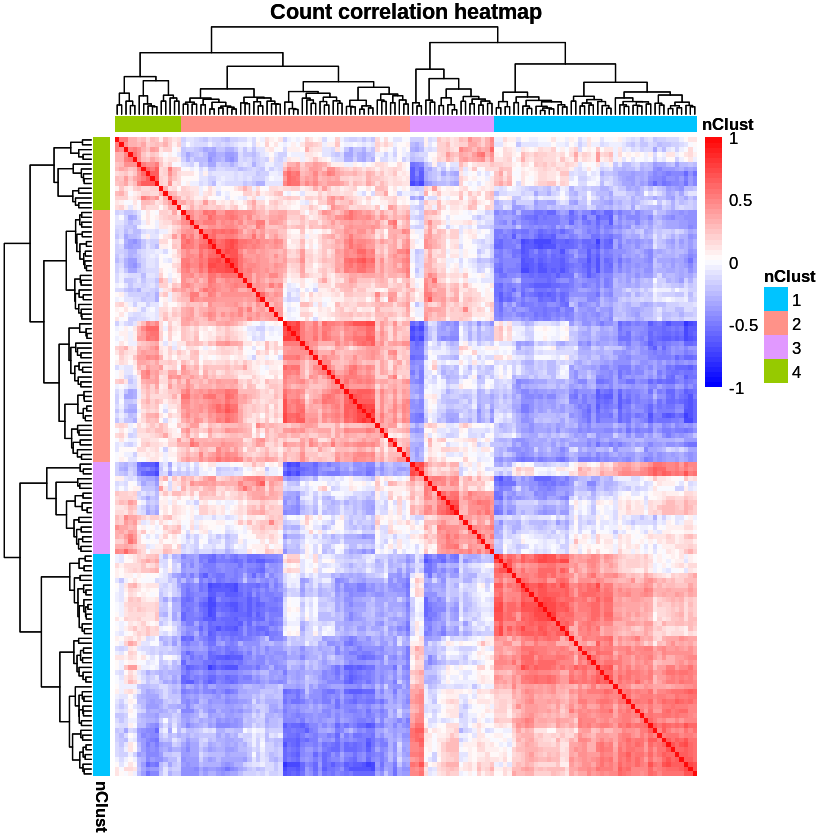

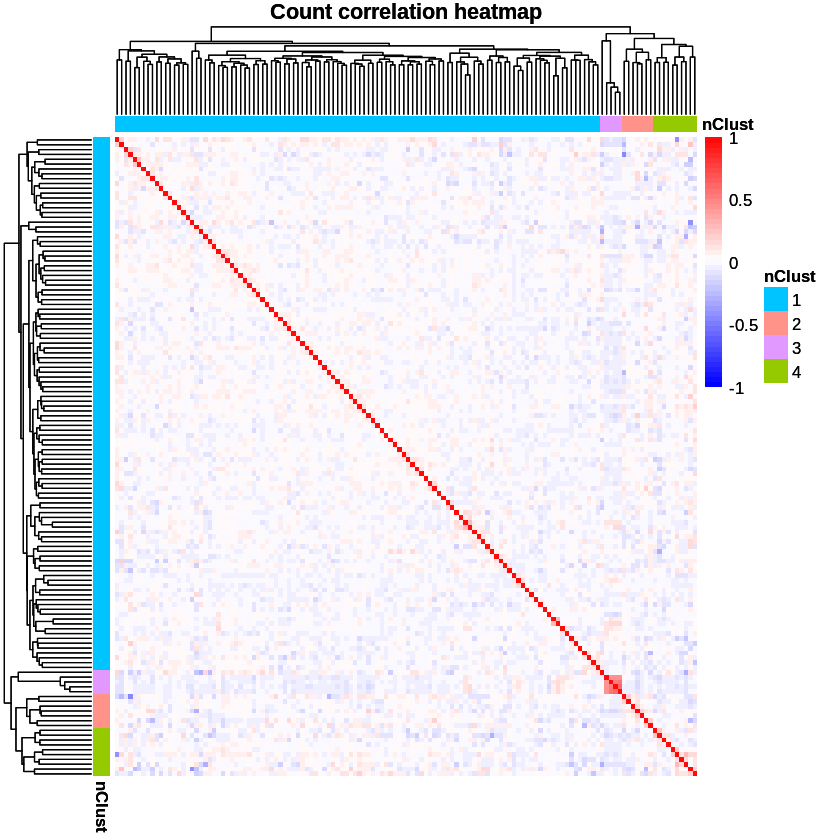

In [ ]:
plotCountCorHeatmap(ods, normalized = FALSE)
plotCountCorHeatmap(ods, normalized = TRUE)

As you can see, prior to application of the autoencoder correlations/patterns of covariability are prominent in the data.  The autoencoder succeeds in removing such confounding factors from the expression data and enables a more accurate comparison of expression, facilitating the discovery of true outlier genes that differ in one individual compared to the cohort.

Now that we have corrected for our hidden confounders and built our statistical models, we can begin to explore our results. We start by exploring some cohort level summaries:

geneID,sampleID,pValue,padjust,zScore,l2fc,rawcounts,normcounts,meanCorrected,theta,aberrant,AberrantBySample,AberrantByGene,padj_rank
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
Gene26508,Proband7,0.000000e+00,0.000000e+00,10.41,3.92,13027,36164.91,2651.78,91.64,TRUE,889,1,1
Gene45283,Proband123,3.759406e-262,5.399635e-258,7.45,3.67,3242,3216.47,293.85,75.45,TRUE,79,5,1
Gene45283,Proband111,2.785532e-203,4.000859e-199,6.79,3.35,3363,2579.40,293.85,75.45,TRUE,470,5,1
Gene38586,Proband15,1.828989e-200,2.626976e-196,6.33,7.20,1130,6231.69,84.26,3.47,TRUE,107,2,1
Gene15339,Proband15,1.929289e-161,1.385519e-157,5.09,8.24,287239,46760.45,502.54,1.21,TRUE,107,2,2
Gene8064,Proband111,1.252915e-64,8.997811e-61,7.76,2.36,8303,5639.42,1156.62,57.51,TRUE,470,2,2


[1] "Summary By Sample"


Proband106 Proband116   Proband7  Proband38  Proband82  Proband12 
       449        502        587        652        930       1349

[1] "Summary By Gene"


Gene23373 Gene28837 Gene35152 Gene55367 Gene17649 Gene23635 
        5         5         5         5         6         6

Warning message:
“Transformation introduced infinite values in continuous y-axis”
Warning message:
“Removed 19 rows containing missing values (geom_bar).”


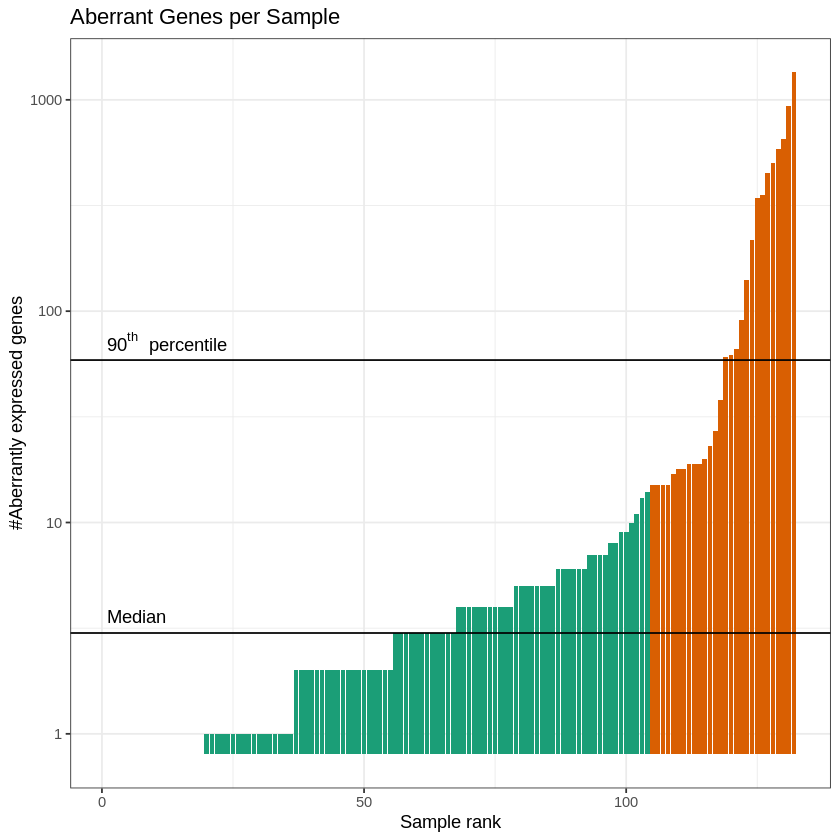

In [ ]:
# See how all results are stored and the top hits
head(res)

# Show number of aberrant results by sample and gene with specified cutoffs
print("Summary By Sample")
tail(sort(aberrant(ods, by="sample", padjCutoff=0.05, zScoreCutoff=3)))
print("Summary By Gene")
tail(sort(aberrant(ods, by="gene", padjCutoff=0.05, zScoreCutoff=3)))

# plot the aberrant events per sample
plotAberrantPerSample(ods, padjCutoff=0.05, zScoreCutoff=3)

From the summary data and graph we can see that the median number of genes aberrant in a proband is around 10, which is a very managable number of genes to examine manually when trying to solve a case. For around 10% of our samples, however, there is widespread gene regulatory disruption resulting in a hundred or more genes being aberrantly expressed. In such samples, it is possible that a regulatory feature itself is the cause of the patient's phenotype (e.g., problems with a transcription factor), or it is possible that some general disregulation is impacting many genes including the one (or more) ultimately responsible for the patients phenotype. In general, cases with many genes aberrantly expressed may be more challenging to solve than those with only a handful that could be exhaustively examined.

## Next we examine proband 9 in greater detail

Proband 15 and her affected sister were born to a consanguineous family and have global developmental delay and refractory epilepsy. 

In [ ]:
print("Outliers for Proband9 with loss of expression:")
print(res[(res$sampleID=="Proband9")&(res$padjust<0.05)&(res$zScore < -3.0),]) 


#"Gene10302" == "PEX1", which at one point was highest rank for this patient
print("Top hits for Gene10302:")
head(res[res$geneID=="Gene10302",])

[1] "Outliers for Proband9 with loss of expression:"
      geneID sampleID       pValue     padjust zScore  l2fc rawcounts
1: Gene10302 Proband9 1.281475e-06 0.003681165  -4.97 -0.46      2335
2: Gene39454 Proband9 1.571739e-06 0.003762482  -5.04 -0.84       381
3: Gene57537 Proband9 5.189402e-06 0.008281710  -5.89 -3.67        25
4: Gene34223 Proband9 7.242260e-06 0.009456416  -4.41 -1.06      2096
   normcounts meanCorrected  theta aberrant AberrantBySample AberrantByGene
1:    2398.14       3313.93 286.15     TRUE               15              1
2:     500.44        896.21  98.47     TRUE               15              1
3:      23.06        300.18   7.20     TRUE               15              1
4:    4337.54       9084.43  48.34     TRUE               15              2
   padj_rank
1:       5.0
2:       6.0
3:       9.0
4:      10.5
[1] "Top hits for Gene10302:"


geneID,sampleID,pValue,padjust,zScore,l2fc,rawcounts,normcounts,meanCorrected,theta,aberrant,AberrantBySample,AberrantByGene,padj_rank
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
Gene10302,Proband9,1.281475e-06,0.003681165,-4.97,-0.46,2335,2398.14,3313.93,286.15,TRUE,15,1,5.0
Gene10302,Proband124,2.658431e-03,0.126016642,2.67,0.26,5180,3931.14,3313.93,286.15,FALSE,101,1,303.0
Gene10302,Proband26,1.543498e-04,0.153639343,3.47,0.33,2510,4138.74,3313.93,286.15,FALSE,10,1,15.0
Gene10302,Proband116,2.885083e-02,0.174419198,1.93,0.19,6293,3746.24,3313.93,286.15,FALSE,894,1,2374.5
Gene10302,Proband111,4.859144e-02,0.299118016,1.73,0.17,6798,3699.22,3313.93,286.15,FALSE,470,1,2333.5
Gene10302,Proband91,4.645896e-02,0.362460669,1.80,0.17,3053,3714.90,3313.93,286.15,FALSE,191,1,1839.0


This table shows that there are five genes in this proband with aberrant loss of expression. It turns out that the top hit (Gene10302) is the PEX1 gene.  Let's have a closer look at it by generating some additional plots to further QC the outlier expression result in this gene to further verify that it is a "real" event and not an artifact of the analyses. 

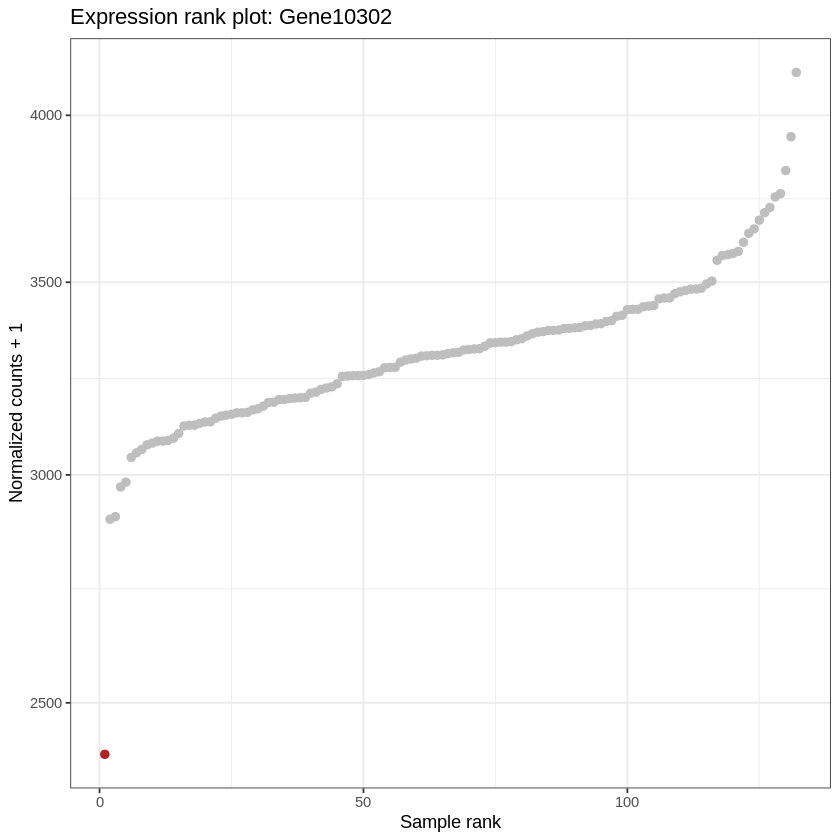

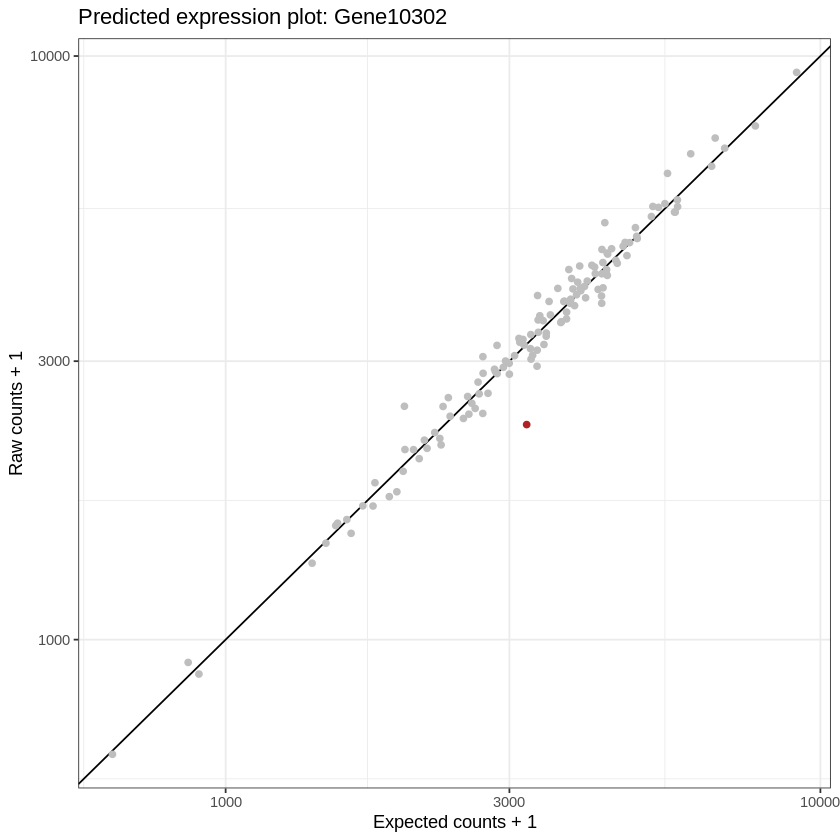

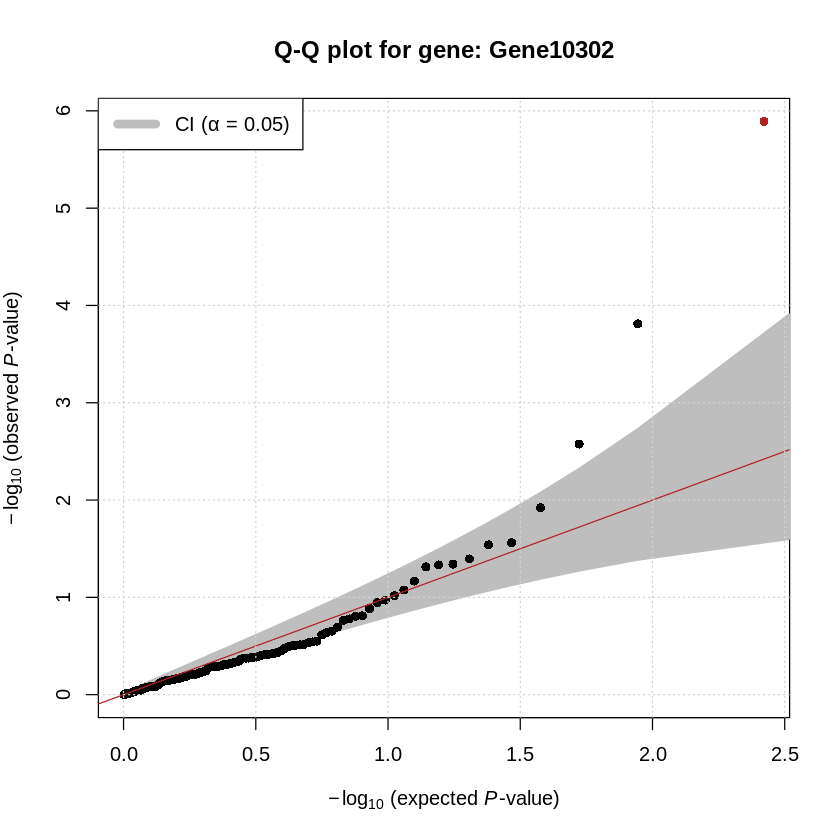

In [ ]:
# some gene level plots
plotExpressionRank(ods, "Gene10302", basePlot=TRUE)
plotExpectedVsObservedCounts(ods, "Gene10302", basePlot=TRUE)
plotQQ(ods, "Gene10302")

In all three of the plots the red dot is the expression of PEX1 in this proband and the grey/black dots are the expression in the other samples in the cohort.  In all plots we see characterstics consistent with this being an outlier from the rest of the population - but what about the biology?

In this case whole exome sequencing of the two sisters and their unaffected parents identified a homozygous synonymous SNV (c.1899A>T, p.Arg633Arg) in the penultimate nucleotide of exon 11 in PEX1 (transcript NM_000466.2) in both girls. SpliceAI (Jaganathan et al., 2019) predicts loss of the exon 11 splice donor (DS_DL=0.7168, DP_DL=-1) without significant gain of a novel donor (DS_DG=0.0104, DP_DG=-7). 

Often we see this where aberrant expression can be contextualized by DNA variation (e.g., deletions or pathogenic mutations) and sometimes other orthogonal RNA-seq analyses.

In the [aberrant splicing tutorial](https://colab.research.google.com/drive/1Dbjn09BLKpH0zh78p7ALNnaE0lLVzcg6?usp=sharing) we will uncover some further information relevant to the loss of expression of PEX1 in this proband, enabling us to conclude a case-solving diagnosis. 


